Recupero immagine random da: https://picsum.photos/224/224...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step


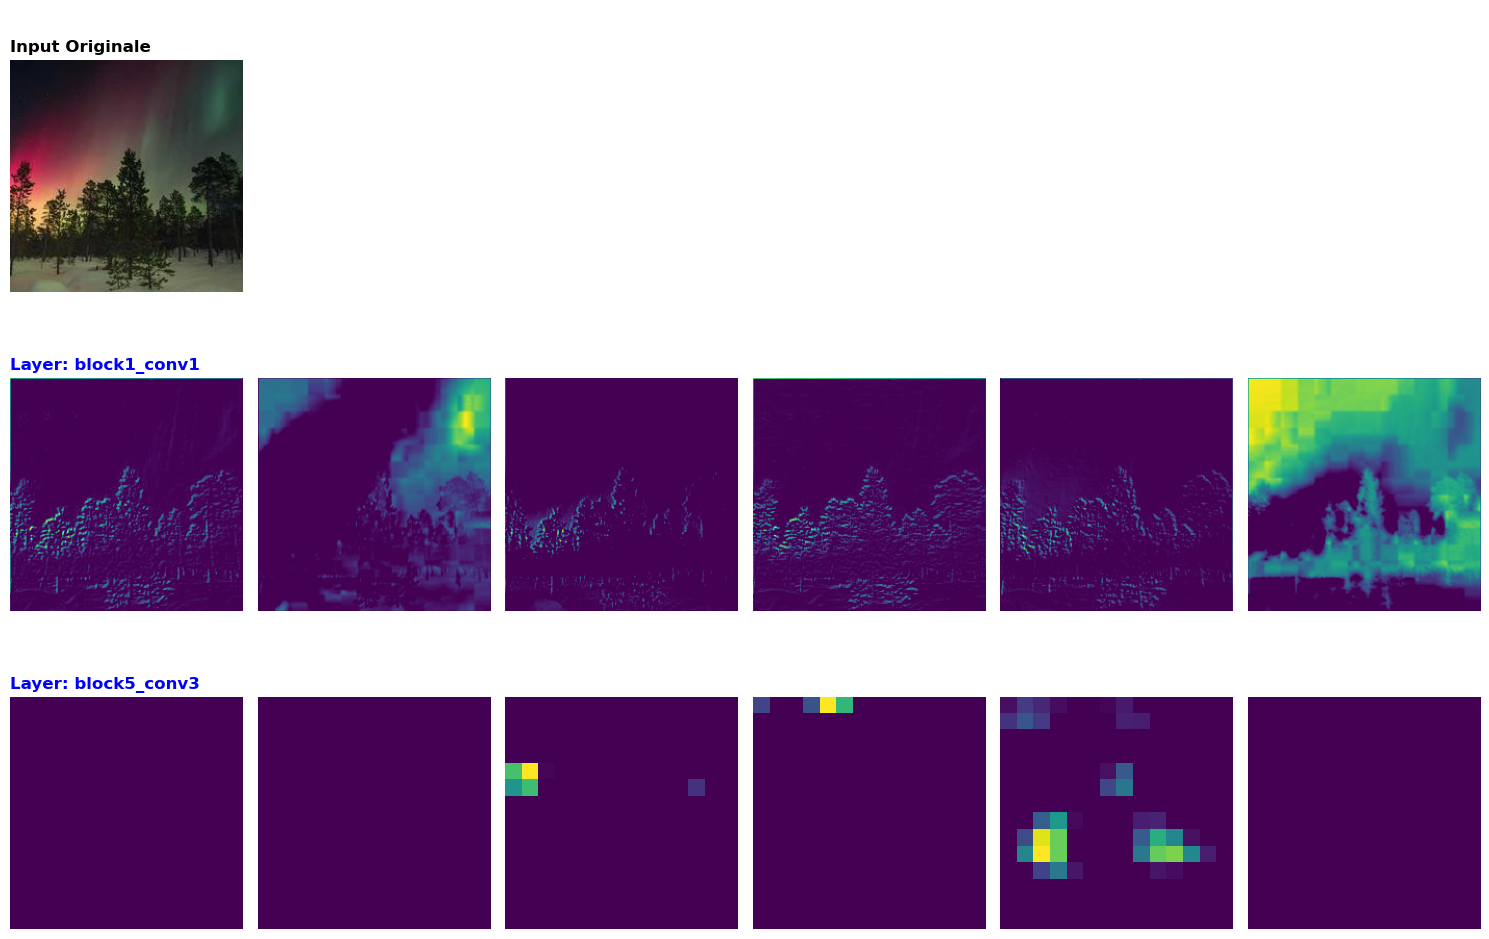

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image

# 1. CONFIGURAZIONE AMBIENTE (Keras 3)
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras.applications.vgg16 import VGG16, preprocess_input
from keras.utils import img_to_array
from keras.models import Model

# --- 2. CARICAMENTO MODELLO ---
# Carichiamo VGG16 senza la "testa" (classificatore finale)
base_model = VGG16(weights='imagenet', include_top=False)

# --- 3. DOWNLOAD E PRE-PROCESSING IMMAGINE ---
def get_web_image(url="https://picsum.photos/224/224"):
    print(f"Recupero immagine random da: {url}...")
    try:
        response = requests.get(url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        return img.resize((224, 224))
    except Exception as e:
        print(f"Errore download: {e}. Uso un placeholder casuale.")
        return Image.fromarray(np.random.randint(0, 255, (224, 224, 3), dtype='uint8'))

original_img = get_web_image()
x = img_to_array(original_img)
x = np.expand_dims(x, axis=0) # Batch dimension
x = preprocess_input(x)       # Normalizzazione ImageNet

# --- 4. CREAZIONE DEL MODELLO DI CONFRONTO ---
# Selezioniamo il primo layer (block1_conv1) e l'ultimo convolutivo (block5_conv3)
target_layers = [base_model.layers[1], base_model.layers[17]]
layer_names = [layer.name for layer in target_layers]

# Modello che restituisce le attivazioni di entrambi i layer
activation_model = Model(inputs=base_model.input, outputs=[l.output for l in target_layers])

# Estrazione delle attivazioni
activations = activation_model.predict(x)

# --- 5. VISUALIZZAZIONE COMPARATIVA ---
def plot_comparison(activation_list, names, n_features=6):
    """
    Confronto tra attivazioni superficiali e profonde.
    """
    # Creiamo una griglia: Righe = (Originale + Layer), Colonne = n_features
    fig, axes = plt.subplots(len(activation_list) + 1, n_features, figsize=(15, 10))
    
    # RIGA 0: Immagine Originale (ripetuta o solo primo slot)
    for j in range(n_features):
        if j == 0:
            axes[0, j].imshow(original_img)
            # FIX: fontweight scritto tutto minuscolo
            axes[0, j].set_title("Input Originale", loc='left', fontweight='bold')
        axes[0, j].axis('off')

    # RIGHE SUCCESSIVE: Feature Maps dei Layer
    for layer_idx, layer_activation in enumerate(activation_list):
        for i in range(n_features):
            ax = axes[layer_idx + 1, i]
            # Usiamo 'viridis' o 'magma' per evidenziare le zone attive
            ax.imshow(layer_activation[0, :, :, i], cmap='viridis')
            ax.axis('off')
            if i == 0:
                ax.set_title(f"Layer: {names[layer_idx]}", loc='left', color='blue', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Eseguiamo il confronto visivo
plot_comparison(activations, layer_names)